[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/OceanNetworksCanada/python-community-notebooks/blob/main/workflows/transit-analysis/transit_identifier.ipynb)

In [1]:
!uv pip install -q cartopy geopy onc xarray

In [2]:
# Bootstrap cell
import sys
from pathlib import Path
import os

def in_colab() -> bool:
    try:
        import google.colab
        return True
    except ImportError:
        return False

def setup_repo_for_shared_imports():
    """
    Locate (or clone, in Colab) the notebook repository and add it to ``sys.path``.

    Notes:
        - In Colab, this ensures the repository exists at
          ``/content/python-community-notebooks`` by cloning it if needed.
        - In local environments, this searches upward from the current working
          directory for ``shared`` to identify the repo root.
        - If a repo root is found, it is prepended to ``sys.path`` to enable
          imports from the repository (e.g., ``shared`` modules).
    """
    repo_dir: Path | None = None

    if in_colab():
        repo_dir = Path('/content/python-community-notebooks')
        if not repo_dir.exists():
            !git clone --depth 1 https://github.com/OceanNetworksCanada/python-community-notebooks.git /content/python-community-notebooks
    else:
        cwd = Path.cwd().resolve()
        for candidate in [cwd, *cwd.parents]:
            if (candidate / 'shared').exists():
                repo_dir = candidate
                break

    if repo_dir is not None and str(repo_dir) not in sys.path:
        sys.path.insert(0, str(repo_dir))



def init_token():   
    """
    Initialize the ONC_TOKEN environment variable.

    Notes:
        - If in Colab, add your ONC_TOKEN secrets by clicking the key icon on the left sidebar
        - If in local, create .env file in the root directory, and add ONC_TOKEN=XXX in your .env file
    """
    if in_colab():
        from google.colab import userdata
        os.environ['ONC_TOKEN'] = userdata.get('ONC_TOKEN')
    else:
        from dotenv import load_dotenv
        load_dotenv()

init_token()
setup_repo_for_shared_imports()

In [3]:
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np
from onc import ONC
import xarray as xr

from shared.IanTBlack_common import format_datetime, convert_scalar_data, split_periods, identify_transit_ports

In [4]:
onc = ONC()

In [5]:
date_from = datetime(2025,11,3,9,0,0)
date_to = datetime(2025,11,3,20,15,0)

# Download NAV
params = {'locationCode': 'TWDP.N1',
          'deviceCategoryCode': 'NAV',
          'qualityControl': 'clean',
          'dateFrom': format_datetime(date_from),
          'dateTo': format_datetime(date_to),
          'fillGaps': False}
json_response = onc.getScalardata(filters = params, allPages=True)
nav = convert_scalar_data(json_response_data = json_response, out_as = 'xarray')


# Download TSG
params = {'locationCode': 'TWDP',
          'deviceCategoryCode': 'TSG',
          'qualityControl': 'clean',
          'dateFrom': format_datetime(date_from),
          'dateTo': format_datetime(date_to),
          'fillGaps': False}
json_response = onc.getScalardata(filters = params, allPages=True)
tsg = convert_scalar_data(json_response_data=json_response, out_as = 'xarray')

## Combine and Interpolate Lat/Lon

In [6]:
ds = xr.combine_by_coords([nav, tsg], combine_attrs = 'drop_conflicts', join = 'outer')

# Linearly interpolate to nearest position. For simplicity, we do not assume a time-lag.
ds['latitude'] = ds['latitude'].interpolate_na(dim = 'time', method = 'linear', max_gap = timedelta(seconds = 5), fill_value = 'extrapolate')
ds['longitude'] = ds['longitude'].interpolate_na(dim = 'time', method = 'linear', max_gap = timedelta(seconds = 5), fill_value = 'extrapolate')

ds = ds.sel(time = tsg.time)  # Select the original TSG timestamps.
ds = ds[['latitude', 'longitude', 'temperature','practical_salinity']]

## Split Transits By Time Gaps

In [7]:
transit_times = split_periods(ds.time, min_gap = 60*5)
transits = [ds.sel(time = slice(t['dateFrom'], t['dateTo'])) for t in transit_times]

# Apply median filter with a window size of 13 samples to each transit.
transits = [t.rolling({'time': 13}, center = True, min_periods = 1).median() for t in transits]

## Plot of Example Transit

Text(0.5, 1.0, '2025-11-03T18:17:06.390')

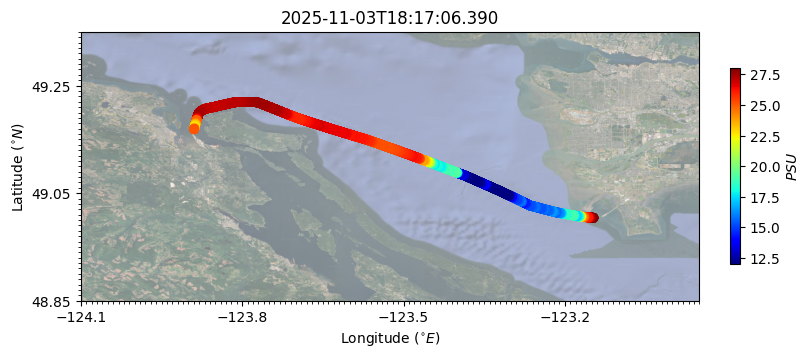

In [8]:
example_transit = transits[-1]

crs = ccrs.PlateCarree()
tile = cimgt.GoogleTiles(style = 'satellite')

lon_min = -124.1
lon_max = -122.95
lat_min = 48.85
lat_max = 49.35

fig, ax = plt.subplots(1,1, figsize = (8,4), constrained_layout = True, subplot_kw = {'projection' : crs})

ax.set_extent([lon_min, lon_max, lat_min , lat_max])
ax.add_image(tile,12,alpha = 0.5)
ax.set_xticks(np.arange(lon_min, lon_max,0.3))
ax.xaxis.set_minor_locator(MultipleLocator(0.01))
ax.set_yticks(np.arange(lat_min, lat_max,0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.01))
ax.set_xlabel(r'Longitude ($^{\circ}E$)')
ax.set_xlabel(r'Longitude ($^{\circ}E$)')
ax.set_ylabel(r'Latitude ($^{\circ}N$)')
ax.set_ylabel(r'Latitude ($^{\circ}N$)')

s0 = ax.scatter(example_transit.longitude, example_transit.latitude, c = example_transit.practical_salinity, cmap = 'jet', transform = crs, vmin = 12, vmax = 28)

fig.colorbar(s0, ax = ax, label = r'$PSU$', shrink = 0.5)

ax.set_title(example_transit.time.min().values)

## Determine Transit Origin

In [9]:
for transit in transits:
    start, end = identify_transit_ports(transit.latitude, transit.longitude)
    print(transit.time.min().values, start, end)

2025-11-03T13:18:00.296 Tsawwassen DukePoint
2025-11-03T15:47:06.338 DukePoint Tsawwassen
2025-11-03T18:17:06.390 Tsawwassen DukePoint
